# Mirror vs. air temperature at fixed time-of-night (`telemetry_mining` rewrite)

Rewrite of `MirrorTemperature.ipynb` using the `telemetry_mining` package. Replaces a raw
`psycopg2.connect(...)` (with a hardcoded password) and manual cursor/dict-building loop
with `Config.default()` + `telemetry_mining.db.fetch_df` -- same reused-connection,
parameterized-query helper the rest of this package uses, returning a DataFrame directly
instead of a list of dicts. The query itself (nightly air/mirror temperature near 05:59:55-60
UTC, the original's proxy for "just before the dome opens") is unchanged. The original
notebook is left untouched for comparison.

In [ ]:
import os
import sys

# Add telemetry_mining to the path. Point DOS_TELEMETRY_MINING_DIR at your own
# checkout (svn co https://desi.lbl.gov/svn/code/online/telemetry_mining/trunk);
# defaults to the maintainer's checkout at NERSC.
TM_DIR = os.getenv("DOS_TELEMETRY_MINING_DIR", os.path.expanduser("~/telemetry_mining-trunk/src"))
sys.path.insert(0, TM_DIR)

import matplotlib.pyplot as plt

from telemetry_mining import Config
from telemetry_mining.db import fetch_df

In [2]:
config = Config.default()

query = """
    SELECT air_temp, mirror_temp, time_recorded
    FROM telemetry.environmentmonitor_telescope
    WHERE date_part('hour', time_recorded) BETWEEN 5.0 AND 5.0
      AND date_part('minute', time_recorded) BETWEEN 59.0 AND 59.0
      AND date_part('second', time_recorded) BETWEEN 55.0 AND 60.0
      AND time_recorded > %s
    ORDER BY time_recorded DESC
    LIMIT 500
"""
temps = fetch_df(config, query, ('2024-07-01 0:0:0',))
print(f'{len(temps)} rows')
temps.head()

500 rows


,air_temp,mirror_temp,time_recorded
0,20.597,18.988,2026-07-16 05:59:59.168246+00:00
1,22.070,18.588,2026-07-15 05:59:57.186829+00:00
2,19.915,18.950,2026-07-14 05:59:57.808694+00:00
3,19.955,19.062,2026-07-13 05:59:57.329619+00:00
4,21.845,19.925,2026-07-12 05:59:56.084978+00:00


In [3]:
temps['deltat'] = temps['air_temp'] - temps['mirror_temp']

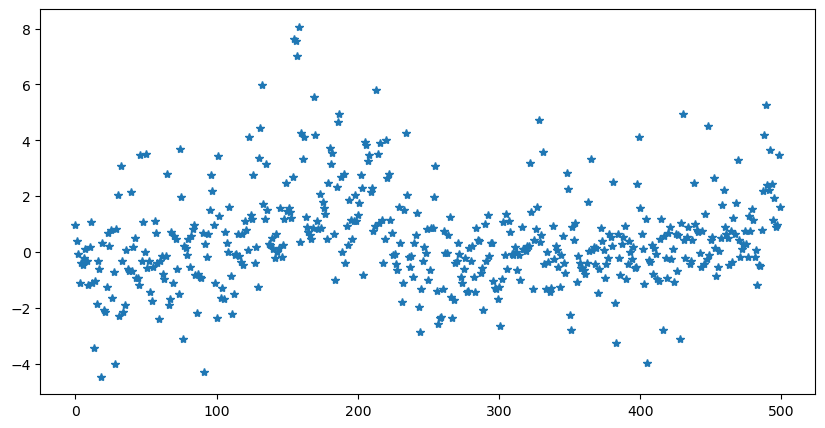

In [4]:
plt.figure(figsize=(10,5))
delta = list(temps['deltat'])[::-1]  # DB gave newest-first; reverse to chronological order, like the original
plt.plot(delta, marker='*', linestyle="")
plt.show()